# Configuración previa

In [1]:
!pip install fitter

# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from fitter import Fitter

from google.colab import drive

# Procesamiento del dataset

In [5]:
def obtener_df_procesado(ruta_dataset):
    IRP_MAXIMO = 300 # Valores que indican cierres de planta
    return (pd.read_csv(ruta_dataset)
            # Conservamos las filas de 'CA15' únicamente
            .query("OperatorComment.str.strip() == 'CA15'")
            .copy()
            .assign(
                    # Pasamos las fechas a DATETIME
                    BegindateTime=lambda x: pd.to_datetime(x['BegindateTime']),
                    EndDateTime=lambda x: pd.to_datetime(x['EndDateTime']),
                    # Generamos
                    TRP=lambda x: x['Duration'] / 60.0,
                    IRP=lambda x: (x['BegindateTime'] - x['EndDateTime']).dt.total_seconds() / 60.0,
                    CCD=lambda x: x['Rejections']
            )
            # Filtramos los IRPs inválidos
            .loc[lambda x: (x['IRP'].notna()) & (x['IRP'] <= IRP_MAXIMO)]
           )

drive.mount('/content/drive')
ruta_dataset = "/content/drive/MyDrive/Facultad/Cuarto Año/Simulación/TP N°4/Entrega/dataset.csv"

df = obtener_df_procesado(ruta_dataset)

# Calculamos mínimos y máximos de cada VA
min_IRP, max_IRP = df['IRP'].min(), df['IRP'].max()
min_TRP, max_TRP = df['TRP'].min(), df['TRP'].max()
min_CCD, max_CCD = df['CCD'].min(), df['CCD'].max()

# Mostramos resultados del procesamiento
print(f"Cantidad de filas: {len(df)}")
print(f"\n")
print(f"Valor mínimo de IRP: {min_IRP}")
print(f"Valor máximo de IRP: {max_IRP}")
print(f"\n")
print(f"Valor mínimo de TRP: {min_TRP}")
print(f"Valor máximo de TRP: {max_TRP}")
print(f"\n")
print(f"Valor mínimo de CCD: {min_CCD}")
print(f"Valor máximo de CCD: {max_CCD}")
print(f"\n")

# Mostramos las primeras 10 filas del dataframe para ver que esté todo OK
print(f"PRIMERAS 10 FILAS DEL DATAFRAME:\n")
print(df[['TRP', 'IRP', 'CCD']].head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cantidad de filas: 238


Valor mínimo de IRP: 6.45
Valor máximo de IRP: 208.68409795333335


Valor mínimo de TRP: 0.5716
Valor máximo de TRP: 8.6222


Valor mínimo de CCD: 0
Valor máximo de CCD: 6


PRIMERAS 10 FILAS DEL DATAFRAME:

           TRP         IRP  CCD
252   1.091383   43.886310    0
424   5.485367  108.877229    1
1827  8.622200   83.049880    0
1829  4.663067  125.282562    0
1835  5.300000  110.174540    0
1837  5.816667   57.302912    0
1851  4.434617   83.848310    0
1854  3.126783   78.865296    0
1872  3.419350   98.479803    0
1882  4.066667  115.697234    0


# Cálculo de las FDPs de mejor ajuste para cada variable aleatoria.

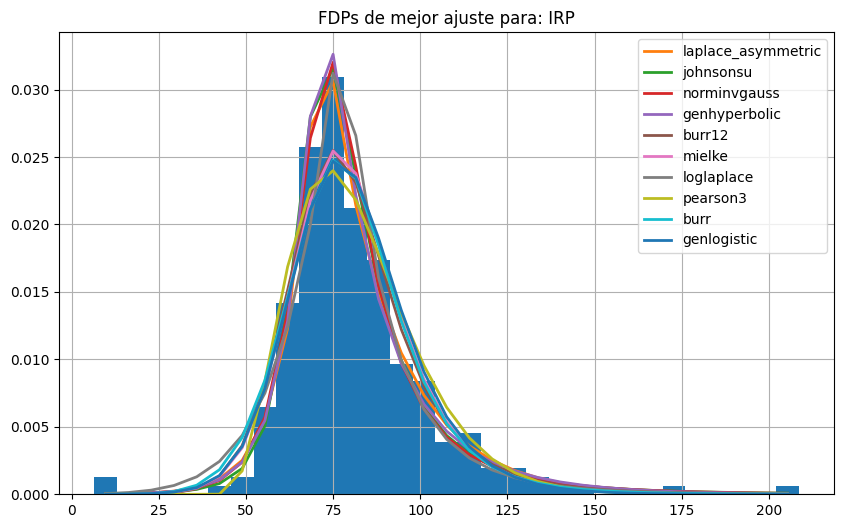

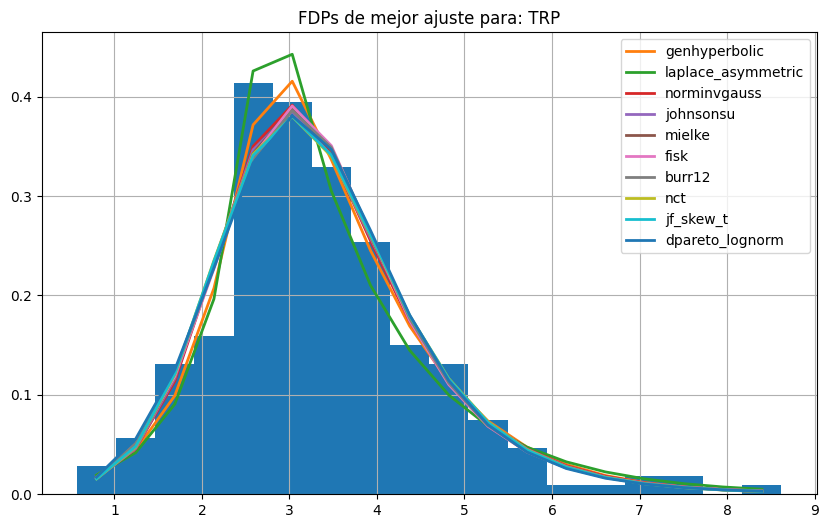

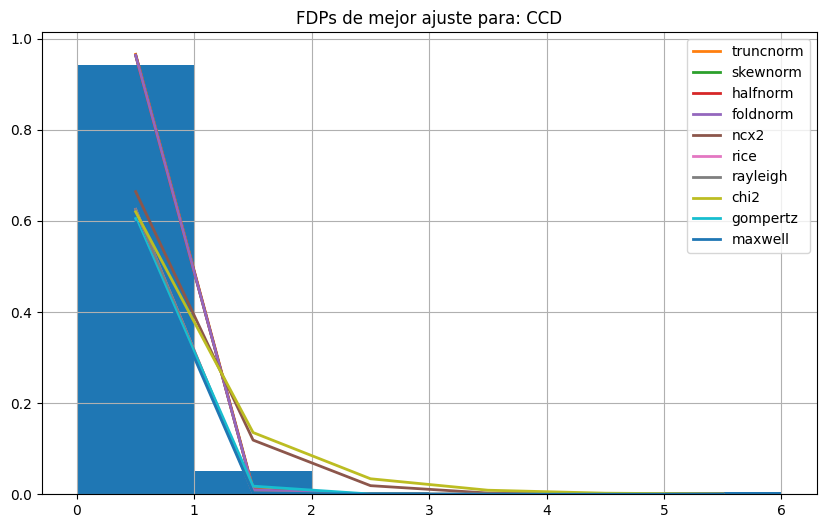

La FDP de mejor ajuste para IRP es: laplace_asymmetric
La FDP de mejor ajuste para TRP es: genhyperbolic
La FDP de mejor ajuste para CCD es: truncnorm


In [6]:
def obtener_fdp_mejor_ajuste(df_estudio, nombre_variable):

  ajustador = Fitter(df_estudio, bins='auto')
  ajustador.fit()
  fdp_mejor_ajuste = ajustador.get_best()

  nombre = list(fdp_mejor_ajuste.keys())[0]
  distribucion = getattr(st, nombre)
  parametros = distribucion.fit(df_estudio)

  # Mostramos las 10 FDPs que mejor se ajustan
  plt.figure(figsize=(10, 6))
  ajustador.summary(10)
  plt.title(f"FDPs de mejor ajuste para: {nombre_variable}")
  plt.show()

  return nombre, parametros, distribucion

# Obtenemos el nombre y los parámetros de la FDP de mejor ajuste para c/u de las VAs.
valores_IRP = df['IRP'].values
nombre_fdp_IRP, parametros_IRP, distribucion_IRP = obtener_fdp_mejor_ajuste(valores_IRP,"IRP")
valores_TRP = df['TRP'].values
nombre_fdp_TRP, parametros_TRP, distribucion_TRP = obtener_fdp_mejor_ajuste(valores_TRP,"TRP")
valores_CCD = df['CCD'].values
nombre_fdp_CCD, parametros_CCD, distribucion_CCD = obtener_fdp_mejor_ajuste(valores_CCD,"CCD")

# Mostramos los resultados:
print(f"La FDP de mejor ajuste para IRP es: {nombre_fdp_IRP}") # Debería mostrar: laplace_asymmetric
print(f"La FDP de mejor ajuste para TRP es: {nombre_fdp_TRP}") # Debería mostrar: genhyperbolic
print(f"La FDP de mejor ajuste para CCD es: {nombre_fdp_CCD}") # Debería mostrar: truncnorm

# Evaluación de las FDPs en los extremos

In [7]:
distribucion_IRP = getattr(st, nombre_fdp_IRP)
distribucion_TRP = getattr(st, nombre_fdp_TRP)
distribucion_CCD = getattr(st, nombre_fdp_CCD)

# Determinamos cuáles son los límites de R para cada VA
min_R_IRP, max_R_IRP = distribucion_IRP.cdf(min_IRP, *parametros_IRP), distribucion_IRP.cdf(max_IRP, *parametros_IRP)
min_R_TRP, max_R_TRP = distribucion_TRP.cdf(min_TRP, *parametros_TRP), distribucion_TRP.cdf(max_TRP, *parametros_TRP)
min_R_CCD, max_R_CCD = distribucion_CCD.cdf(min_CCD, *parametros_CCD), distribucion_CCD.cdf(max_CCD, *parametros_CCD)

print(f"IRP: R va de {min_R_IRP:.4f} a {max_R_IRP:.4f}")
print(f"TRP: R va de {min_R_TRP:.4f} a {max_R_TRP:.4f}")
print(f"CCD: R va de {min_R_CCD:.4f} a {max_R_CCD:.4f}\n")

IRP: R va de 0.0001 a 0.9996
TRP: R va de 0.0062 a 0.9981
CCD: R va de 0.0000 a 1.0000



# Simulación

In [ ]:
# Subrutinas para la generación de VAs

def IRP():
    while True:
        v = distribucion_IRP.rvs(*parametros_IRP)
        if min_IRP <= v <= max_IRP:
            return v

def TRP():
    while True:
        v = distribucion_TRP.rvs(*parametros_TRP)
        if min_TRP <= v <= max_TRP:
            return v

def CCD():
    while True:
        v = distribucion_CCD.rvs(*parametros_CCD)
        if min_CCD <= v <= max_CCD:
            return int(round(v))

# Declaración de constantes:

COSTO_PIEZA = 30                      # en USD
COSTO_HORA_OCIOSA = 500               # en USD
MINUTOS_POR_MES = 60 * 24 * 30
CUPLAS_FABRICADAS_POR_MINUTO = 1 / 5  # Una cada 5 minutos
MESES_A_SIMULAR = 240                 # 10 años

# Declaración del tiempo final de simulación:

TF = MESES_A_SIMULAR * MINUTOS_POR_MES

def simular(n):

  # Fijación de las condiciones iniciales:

  T = 0     # Tiempo de simulación
  NP = n    # Número de piezas en stock (arranca con una entrega)
  CPUM = 0  # Cantidad de piezas "CA15" utilizadas este mes
  TCD = 0   # Total de cuplas descartadas
  STO = 0   # Sumatoria de tiempo ocioso (minutos)
  STF = 0   # Sumatoria de tiempo funcionando
  RSMS = [] # Registro de SMS's (Stock mensual sobrante)
  TPEP = MINUTOS_POR_MES

  TPRP = T + IRP()

  while T < TF:

    if TPRP < TPEP: # Reemplazo de una pieza

      STF = STF + (TPRP - T)
      T = TPRP
      TCD = TCD + CCD()
      CPUM = CPUM + 1

      if NP > 0: # Si hay stock

        NP = NP - 1
        t = TRP()
        STO = STO + t
        T = T + t
        TPRP = T + IRP()

      else: # Si no hay stock

        STO = STO + (TPEP - T)
        T = TPEP
        TPRP = TPEP

    else: # Entrega de piezas

      if T < TPEP and TPRP > TPEP:
        STF = STF + (TPEP - T)

      T = TPEP

      SMS = max(0, n - CPUM) # Cálculo de SMS
      RSMS.append(SMS) # Registro de SMS (para el promedio)

      CPUM = 0 # Cambio de mes, reinicio de contador

      NP += n
      TPEP = T + MINUTOS_POR_MES

  # Cálculo de variables de resultado:

  STO_promedio = (STO / 60.0) / MESES_A_SIMULAR

  PTO = (STO / TF) * 100
  PCD = (TCD / (STF * CUPLAS_FABRICADAS_POR_MINUTO)) * 100
  SMSP = np.mean(RSMS) if RSMS else 0
  CTMP = (SMSP * COSTO_PIEZA) + (STO_promedio * COSTO_HORA_OCIOSA)

  return PTO,PCD,SMSP,CTMP

# Declaración de escenarios
rango_n = [400,425,450,500,510,520,530,540,600,800]

print(f"Haciendo una simulación de {MESES_A_SIMULAR} meses para cada n")
print("-" * 75)
print(f"{'n':<12} | {'PTO':<12} | {'PCD':<10} | {'SMSP':<10} | {'CTMP'}")
print("-" * 75)
for n in rango_n:
    PTO,PCD,SMSP,CTMP = simular(n)
    # Impresión de resultados
    print(f"{n:<12} | {PTO:<12.2f} | {PCD:<10.2f} | {SMSP:<10.2f} | {CTMP:<11.2f}")

Haciendo una simulación de 240 meses para cada n
---------------------------------------------------------------------------
n            | PTO          | PCD        | SMSP       | CTMP
---------------------------------------------------------------------------
400          | 24.85        | 1.85       | 0.00       | 89462.99   
425          | 20.29        | 1.86       | 0.00       | 73055.78   
450          | 15.37        | 1.85       | 0.00       | 55333.27   
500          | 6.09         | 1.84       | 0.01       | 21940.62   
510          | 4.14         | 1.84       | 1.78       | 14941.28   
520          | 4.00         | 1.83       | 9.10       | 14655.19   
530          | 3.99         | 1.86       | 18.72      | 14940.56   
540          | 3.99         | 1.86       | 28.44      | 15227.22   
600          | 3.99         | 1.84       | 88.69      | 17037.50   
800          | 4.00         | 1.83       | 289.27     | 23062.13   
